celda 1 
# 🚴 Cálculo de Coeficiente Aerodinámico (CdA) desde .fit
Este cuaderno estima el CdA y el coeficiente de rodadura (Crr) analizando un archivo `.fit`.

**Requerimientos:**
- `fitdecode`: Para leer archivos Garmin/Suunto/Wahoo.
- `scipy`: Para la optimización numérica.
- `pandas`: Manejo de datos.
- `matplotlib`: Gráficos.

In [10]:
# Solo necesario la primera vez que ejecutas el cuaderno
%pip install fitdecode numpy scipy pandas matplotlib
%pip install --upgrade fitdecode

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


librerias

In [2]:
import fitdecode
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Configuración de gráficos
plt.style.use('seaborn-v0_8') 
print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


 1. Función de carga

In [3]:
def cargar_fit(ruta_archivo):
    registros = []
    
    with fitdecode.FitReader(ruta_archivo) as fit:
        for frame in fit:
            # Filtra headers y definiciones; solo procesa mensajes de datos reales
            if isinstance(frame, fitdecode.FitDataMessage) and frame.name == 'record':
                # Construye un mapa de campos presentes para evitar errores al pedir campos ausentes
                campos = {f.name: f.value for f in frame.fields if f.value is not None}
                
                # Algunos dispositivos usan nombres alternativos
                p = campos.get('power', campos.get('enhanced_power'))
                v = campos.get('enhanced_speed', campos.get('speed'))
                h = campos.get('enhanced_altitude', campos.get('altitude'))
                t = campos.get('timestamp')
                
                # Solo guardamos filas completas para el modelo
                if p is not None and v is not None and h is not None and t is not None:
                    registros.append({
                        'timestamp': t,
                        'potencia': p,
                        'velocidad': v,
                        'altitud': h
                    })
                    
    if not registros:
        raise ValueError("❌ No se encontraron registros 'record' válidos con potencia en el .fit")
        
    return pd.DataFrame(registros)

2. Preprocesamiento

In [4]:
def preprocesar_datos(df):
    """
    Calcula derivadas: aceleración, pendiente y distancia delta.
    Filtra datos con poca señal (paradas, bajas velocidades).
    """
    df = df.copy()
    
    # Si falta altitud, la completamos para no descartar puntos útiles.
    # Interpola huecos internos y rellena extremos con el valor más cercano.
    if 'altitud' in df.columns:
        df['altitud'] = df['altitud'].interpolate(limit_direction='both').ffill().bfill()
    
    # Cálculo de diferencias (delta)
    df['delta_t'] = df['timestamp'].diff().dt.total_seconds()
    df['delta_v'] = df['velocidad'].diff()
    df['delta_h'] = df['altitud'].diff() if 'altitud' in df.columns else 0.0
    
    # Eliminar primera fila (que será NaN por el diff)
    df = df.iloc[1:].copy()
    
    # Filtrado de calidad:
    # 1. Velocidad mínima (ej. > 10 km/h o 2.7 m/s) para evitar paradas
    # 2. Potencia mínima positiva (ej. > 30W) para evitar frentes falsos
    df = df[
        (df['velocidad'] > 3.0) & 
        (df['potencia'] > 30) &
        (df['delta_t'] < 5)  # Evitar saltos de tiempo > 5s (pausas)
    ].copy()
    
    # Derivadas físicas
    df['aceleracion'] = df['delta_v'] / df['delta_t']
    df['distancia_segmento'] = df['velocidad'] * df['delta_t']
    
    # Si no hay altitud útil, asumimos tramo llano (pendiente = 0).
    if 'delta_h' in df.columns:
        ratio = np.divide(
            df['delta_h'].fillna(0.0),
            df['distancia_segmento'].replace(0, np.nan),
            out=np.zeros(len(df), dtype=float),
            where=df['distancia_segmento'].replace(0, np.nan).notna()
        )
        df['pendiente'] = np.arcsin(np.clip(ratio, -0.5, 0.5))
    else:
        df['pendiente'] = 0.0
    
    return df

print("📉 Función `preprocesar_datos` definida")

📉 Función `preprocesar_datos` definida


 3. Modelo Matemático

In [5]:
def modelo_potencia(params, df, masa_ciclista=75, masa_bici=8, g=9.81, rho=1.15, eficiencia=0.97):
    """
    Calcula la Potencia Predicha (W) basándose en CdA y Crr dados.
    
    Parametros:
    - params: lista [CdA, Crr]
    - rho: densidad del aire (aprox 1.225 a nivel mar)
    - eficiencia: eficiencia transmisión (0.97 ~ 97%)
    """
    cda, crr = params
    masa_total = masa_ciclista + masa_bici
    
    v = df['velocidad'].values
    a = df['aceleracion'].values
    sin_theta = np.sin(df['pendiente'].values)
    cos_theta = np.cos(df['pendiente'].values)
    
    # Componentes de fuerza
    F_aero = 0.5 * rho * cda * (v**2)
    F_gravedad = masa_total * g * sin_theta
    F_rodadura = masa_total * g * crr * cos_theta
    F_inercia = masa_total * a
    
    # Potencia = Fuerza Total * Velocidad / Eficiencia
    return (F_aero + F_gravedad + F_rodadura + F_inercia) * v / eficiencia

print("⚙️ Función `modelo_potencia` definida")

⚙️ Función `modelo_potencia` definida


 4. Optimización y Resultados

In [6]:
def estimar_cda(df, masa_total=83):
    """
    Usa Nelder-Mead/L-BFGS para minimizar el error entre Potencia Real y Modelo.
    """
    pot_real = df['potencia'].values
    
    # Función objetivo a minimizar: Error Cuadrático Medio (MSE)
    def funcion_error(params):
        pot_modelo = modelo_potencia(params, df, masa_ciclista=masa_total-8)
        return np.mean((pot_real - pot_modelo)**2)
    
    # Valor inicial [CdA, Crr]
    # CdA típico: 0.30, Crr típico asfalto: 0.005
    x0 = [0.300, 0.005]
    
    # Límites físicos (bounds) para evitar soluciones absurdas
    # CdA: 0.18 (pro) a 0.50 (paseo)
    # Crr: 0.002 (pista) a 0.015 (grava)
    bounds = [(0.15, 0.60), (0.002, 0.015)]
    
    print("⏳ Optimizando parámetros...")
    resultado = minimize(funcion_error, x0, bounds=bounds)
    
    if resultado.success:
        cda_opt, crr_opt = resultado.x
        mse_final = resultado.fun
        
        print(f"\n🏆 RESULTADO FINAL:")
        print(f"   CdA estimado: {cda_opt:.4f} m²")
        print(f"   Crr estimado: {crr_opt:.4f}")
        print(f"   Error (MSE):  {mse_final:.1f} W²")
        
        return cda_opt, crr_opt, df['potencia'], modelo_potencia(resultado.x, df, masa_ciclista=masa_total-8)
    else:
        print("❌ Error en la optimización.")
        return None

print("🎯 Función `estimar_cda` definida")

🎯 Función `estimar_cda` definida


Ejecución Principal (¡Edita la ruta!)

In [7]:
# 🛑 IMPORTANTE: Sube tu archivo .fit al notebook o cambia la ruta aquí
ruta_fit = './data/i150002737.fit'  # Cambia esta ruta al nombre de tu archivo .fit

try:
    # 1. Cargar
    df_raw = cargar_fit(ruta_fit)
    
    # 2. Preprocesar
    df_pro = preprocesar_datos(df_raw)
    
    print(f"📊 Datos analizados: {len(df_pro)} registros de alta calidad.")
    
    # 3. Estimar (Ajusta la masa total: ciclista + bici + ropa)
    masa_total = 80.0 
    cda, crr, pot_medida, pot_modelo = estimar_cda(df_pro, masa_total)
    
except FileNotFoundError:
    print(f"❌ Archivo '{ruta_fit}' no encontrado. Asegúrate de subir el archivo .fit.")
except Exception as e:
    print(f"⚠️ Ocurrió un error: {e}")

📊 Datos analizados: 7910 registros de alta calidad.
⏳ Optimizando parámetros...

🏆 RESULTADO FINAL:
   CdA estimado: 0.1500 m²
   Crr estimado: 0.0150
   Error (MSE):  59668.7 W²


6. Visualización

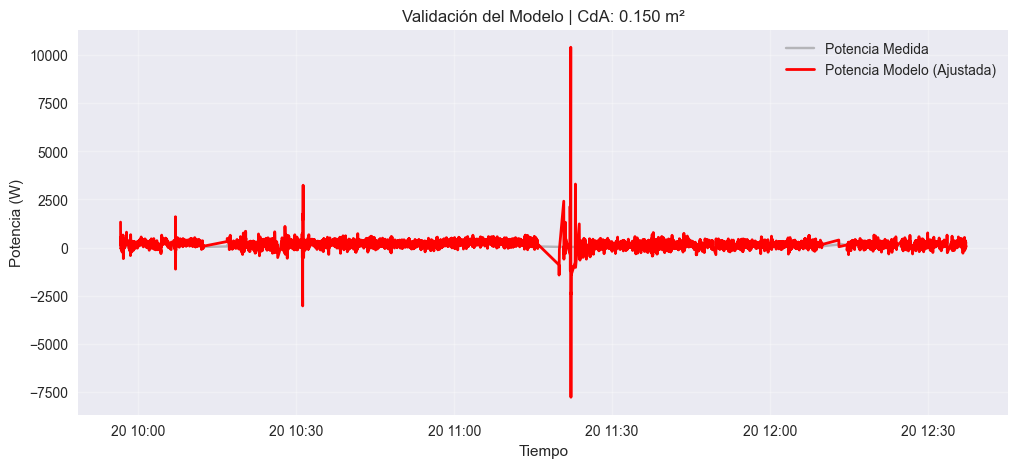

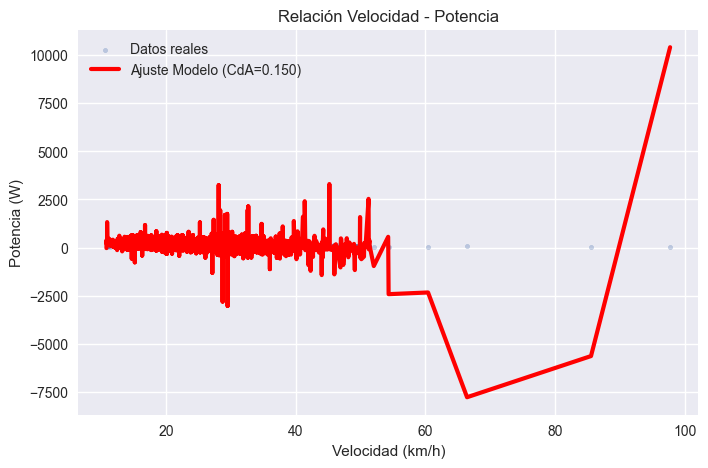

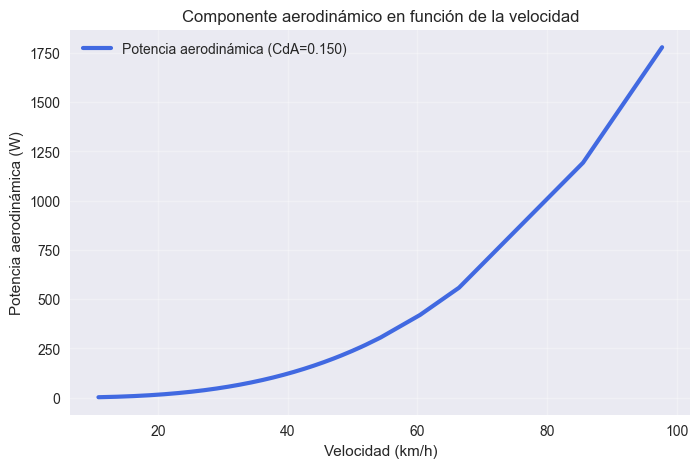

In [8]:
if 'pot_medida' in locals():
    plt.figure(figsize=(12, 5))
    
    # Gráfico Potencia vs Tiempo
    plt.plot(df_pro['timestamp'], pot_medida, color='gray', alpha=0.5, label='Potencia Medida')
    plt.plot(df_pro['timestamp'], pot_modelo, color='red', linewidth=2, label='Potencia Modelo (Ajustada)')
    
    plt.title(f'Validación del Modelo | CdA: {cda:.3f} m²')
    plt.ylabel('Potencia (W)')
    plt.xlabel('Tiempo')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Gráfico Velocidad vs Potencia (Scatter)
    plt.figure(figsize=(8, 5))
    plt.scatter(df_pro['velocidad'] * 3.6, pot_medida, alpha=0.3, s=10, label='Datos reales')
    
    # Ordenar por velocidad para dibujar la curva de tendencia limpia
    df_sorted = df_pro.sort_values('velocidad')
    plt.plot(df_sorted['velocidad'] * 3.6, pot_modelo[np.argsort(df_pro['velocidad'].values)], 
             color='red', linewidth=3, label=f'Ajuste Modelo (CdA={cda:.3f})')
             
    plt.xlabel('Velocidad (km/h)')
    plt.ylabel('Potencia (W)')
    plt.title('Relación Velocidad - Potencia')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Gráfico del componente aerodinámico usando el CdA estimado
    rho_ref = 1.15
    eficiencia_ref = 0.97
    v_sorted = df_sorted['velocidad'].values
    v_kmh_sorted = v_sorted * 3.6
    pot_aero_cda = 0.5 * rho_ref * cda * (v_sorted ** 3) / eficiencia_ref
    
    plt.figure(figsize=(8, 5))
    plt.plot(v_kmh_sorted, pot_aero_cda, color='royalblue', linewidth=3,
             label=f'Potencia aerodinámica (CdA={cda:.3f})')
    plt.xlabel('Velocidad (km/h)')
    plt.ylabel('Potencia aerodinámica (W)')
    plt.title('Componente aerodinámico en función de la velocidad')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()